# Telco Customer Churn Prediction
**Goal:** predict customer churn and provide a reusable prediction API.

Workflow: Business Problem → Data Preparation → EDA → Feature Engineering → Class Imbalance Handling → Decision Tree Experiments → Hyperparameter Tuning → Additional Model Comparison → Evaluation → Interpretation → Business Layer → Saved Pipeline → API.

## 1. Load and inspect the data

In [63]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import sys
import os

project_dir = os.path.abspath("..")
sys.path.insert(0, project_dir)
from feature_engineering import feature_engineering

df = pd.read_csv("../data/TelcoCustomerChurn.csv")
data_dict = pd.read_csv("../data/TelcoCustomerChurn - Data Dictionary.csv")
print("Shape:", df.shape)
display(df.head())
display(data_dict)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


In [64]:
display(df.dtypes)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False))
print("Target distribution:")
display(df["Churn"].value_counts())
display((df["Churn"].value_counts(normalize=True)*100).round(2))

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Duplicate rows: 0
Missing values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

### Preparation decisions
- `customerID` is an identifier, so it is excluded from modelling.
- `TotalCharges` is text in the supplied file and is converted to numeric.
- Categorical variables are one-hot encoded.
- Numeric values are median-imputed and categorical values are most-frequent imputed.
- `handle_unknown="ignore"` protects inference against unseen categories.
- Use a 70:30 stratified split with `random_state=42`.
- Feature engineering is embedded in the sklearn pipeline to avoid train/inference mismatch.

## 2. Exploratory Data Analysis

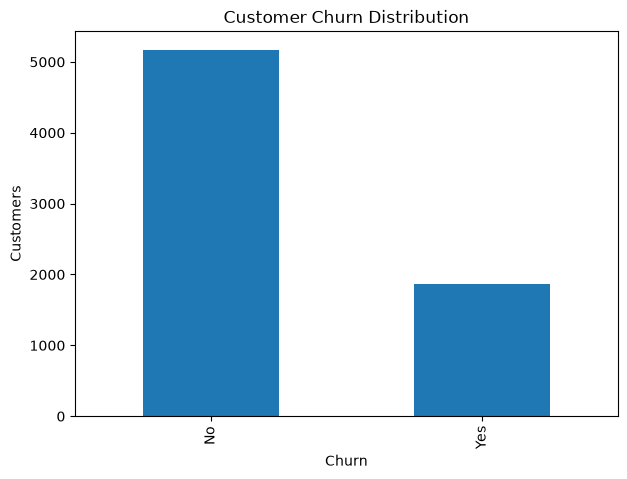

In [65]:
plt.figure(figsize=(7,5))
df["Churn"].value_counts().reindex(["No","Yes"]).plot(kind="bar")
plt.title("Customer Churn Distribution"); plt.xlabel("Churn"); plt.ylabel("Customers"); plt.show()

# Insight: churn is the minority class, so accuracy should be considered together with recall, precision and F1.

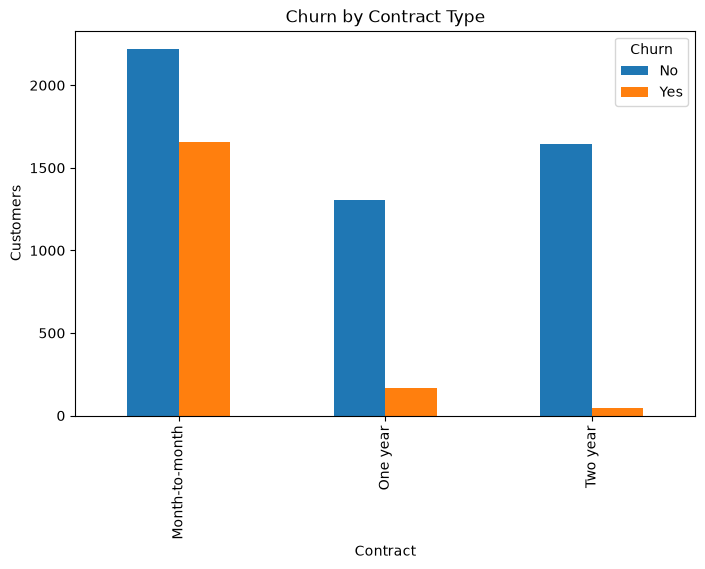

In [41]:
ct=pd.crosstab(df["Contract"],df["Churn"]).reindex(columns=["No","Yes"],fill_value=0)
ct.plot(kind="bar",figsize=(8,5)); plt.title("Churn by Contract Type"); plt.xlabel("Contract"); plt.ylabel("Customers"); plt.show()

# Insight: contract commitment is a key customer-lifecycle attribute to investigate for retention.

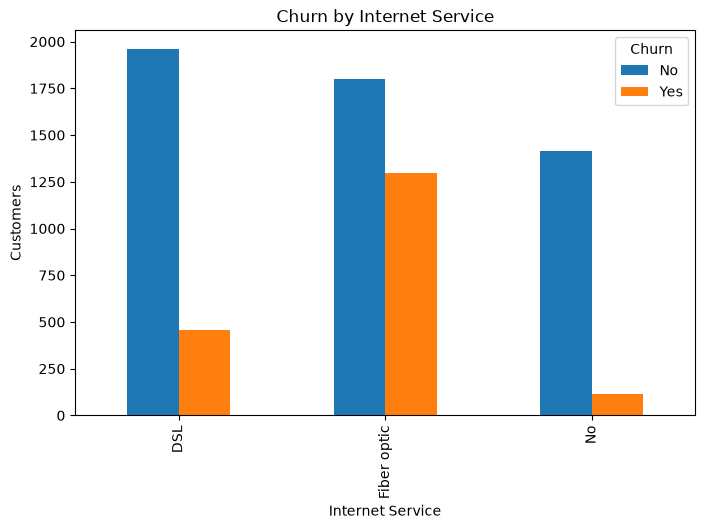

In [42]:
ct=pd.crosstab(df["InternetService"],df["Churn"]).reindex(columns=["No","Yes"],fill_value=0)
ct.plot(kind="bar",figsize=(8,5)); plt.title("Churn by Internet Service"); plt.xlabel("Internet Service"); plt.ylabel("Customers"); plt.show()

# Insight: churn composition differs across internet service types.

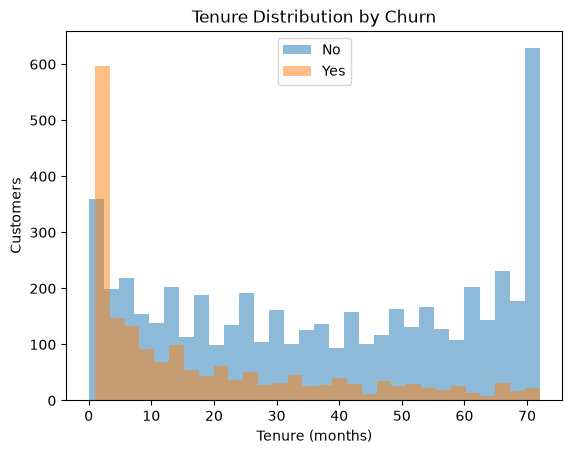

In [43]:
for label in ["No","Yes"]:
    plt.hist(df.loc[df["Churn"]==label,"tenure"],bins=30,alpha=.5,label=label)
plt.title("Tenure Distribution by Churn"); plt.xlabel("Tenure (months)"); plt.ylabel("Customers"); plt.legend(); plt.show()

# Insight: tenure helps describe lifecycle-related churn behaviour.

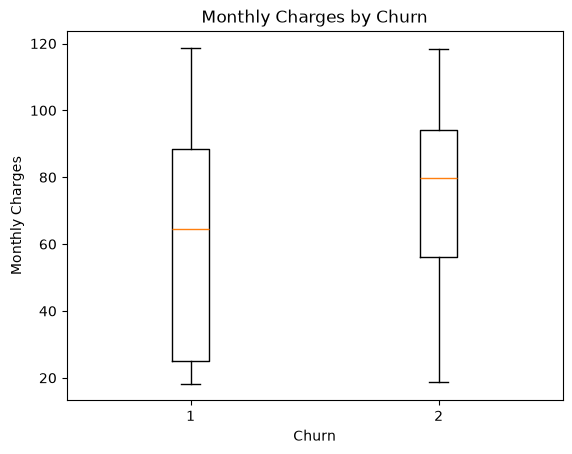

In [44]:
groups=[df.loc[df["Churn"]==label,"MonthlyCharges"].dropna() for label in ["No","Yes"]]
plt.boxplot(groups,label=["No","Yes"]); plt.title("Monthly Charges by Churn"); plt.xlabel("Churn"); plt.ylabel("Monthly Charges"); plt.show()

# Insight: charge distribution can indicate price/value pressure among churners.

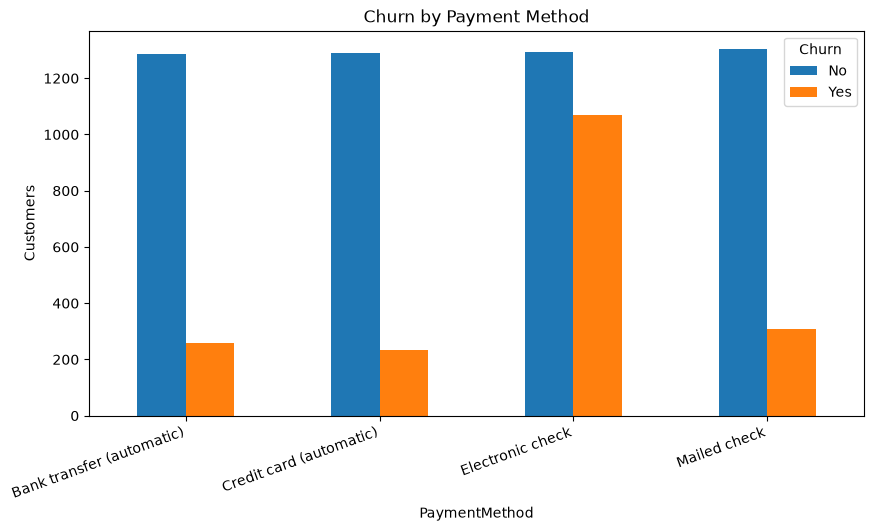

In [45]:
ct=pd.crosstab(df["PaymentMethod"],df["Churn"]).reindex(columns=["No","Yes"],fill_value=0)
ct.plot(kind="bar",figsize=(10,5)); plt.title("Churn by Payment Method"); plt.xticks(rotation=20,ha="right"); plt.ylabel("Customers"); plt.show()

# Insight: payment method is a useful customer-behaviour/operational attribute for retention analysis.

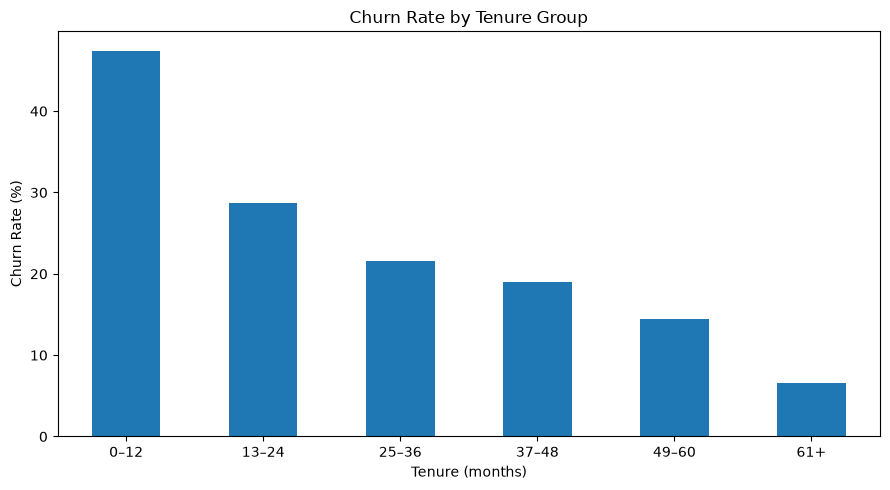

In [46]:
# Churn rate by customer tenure group
df_eda = df.copy()
bins=[-1,12,24,36,48,60,999]
labels=['0–12','13–24','25–36','37–48','49–60','61+']
df_eda['tenure_group']=pd.cut(df_eda['tenure'],bins=bins,labels=labels)
tenure_churn=(df_eda.groupby('tenure_group',observed=False)['Churn']
              .apply(lambda s:(s=='Yes').mean()*100).reindex(labels))
plt.figure(figsize=(9,5))
tenure_churn.plot(kind='bar')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# Insight: this shows where customers are most vulnerable in the relationship lifecycle,
# helping retention teams focus onboarding and early-lifecycle interventions.

## 3. Feature engineering

**Feature 1 — `avg_monthly_charge`:** TotalCharges / tenure, falling back to MonthlyCharges when tenure is zero. It represents effective average spend.

**Feature 2 — `service_count`:** number of selected services marked Yes. It provides a simple proxy for breadth of engagement.

## 4. Model development

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

print(feature_engineering.__module__)
# ============================================================
# GRID SEARCH - DECISION TREE
# ============================================================

# Use the shared feature engineering function
preview = feature_engineering(X_train)

# Identify columns correctly
cat = preview.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

num = preview.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(cat)

print("\nNumeric columns:")
print(num)


# ============================================================
# PREPROCESSOR
# ============================================================

tuning_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num
        ),
        (
            "cat",
            Pipeline([
                (
                    "imp",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "ohe",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            cat
        )
    ]
)


# ============================================================
# PIPELINE
# ============================================================

tuning_pipeline = Pipeline([
    (
        "features",
        FunctionTransformer(
            feature_engineering,
            validate=False
        )
    ),
    (
        "preprocessor",
        tuning_preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])



# ============================================================
# PARAMETERS TO TEST
# ============================================================

param_grid = {
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__min_samples_leaf": [20, 30, 50]
}


# ============================================================
# GRID SEARCH
# ============================================================

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)


# ============================================================
# FIT
# ============================================================

print("\nStarting GridSearchCV...")

grid_search.fit(
    X_train,
    y_train
)

print("\nGridSearchCV completed successfully!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(round(grid_search.best_score_, 4))

feature_engineering
Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'service_count']
Pipeline(steps=[('features',
                 FunctionTransformer(func=<function feature_engineering at 0x000001D31B424720>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'avg_monthly_charge',
            

## 4A. Bonus — Hyperparameter tuning

Grid search is performed **only on the training set** using 5-fold cross-validation and F1 as the selection metric. 
The held-out 30% test set remains untouched until final evaluation.

Search space: `max_depth = [3, 4, 5, 6]` and `min_samples_leaf = [20, 30, 50]`.

This improves the solution without making the model unnecessarily complex.

In [70]:
print("GridSearch object:", grid_search)
print("Best parameters:", grid_search.best_params_)
print("Best estimator:", grid_search.best_estimator_)
# ============================================================
# EVALUATE TUNED DECISION TREE
# ============================================================

# Best model selected by GridSearchCV
tuned_model = grid_search.best_estimator_

# Predict on untouched test set
y_pred_tuned = tuned_model.predict(X_test)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Tuned Decision Tree Performance")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

GridSearch object: GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('features',
                                        FunctionTransformer(func=<function feature_engineering at 0x000001D31B424720>)),
                                       ('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'avg_monthly_charge',
                                                                        

In [88]:
import pickle
import os

model_path = "../model/churn_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(tuning_pipeline, f)

print("Model saved to:", os.path.abspath(model_path))

with open("../model/churn_model.pkl", "rb") as f:
    test_model = pickle.load(f)

print("Model loaded successfully!")
print(
    test_model.named_steps["features"].func.__module__
)

Model saved to: c:\Users\debolinamajumdar\OneDrive - Nagarro\Desktop\study\NAGP\Home Assignment - Technology Band III\customer_churn_project_enhanced\customer_churn_project\model\churn_model.pkl
Model loaded successfully!
feature_engineering


## 4B. Bonus — Compare an additional model

A Logistic Regression model is added as a simple benchmark. It uses the **same feature engineering and preprocessing pipeline**, so the comparison is fair.

The Decision Tree remains the primary model because it is the required model and is easier to explain visually to business users.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer


# ============================================================
# LOGISTIC REGRESSION - BONUS MODEL
# ============================================================

# Use your existing feature engineering function
preview = feature_engineering(X_train)

# Correctly identify column types
cat = preview.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

num = preview.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(cat)

print("\nNumeric columns:")
print(num)


# ------------------------------------------------------------
# Create a fresh preprocessor
# ------------------------------------------------------------

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num
        ),
        (
            "cat",
            Pipeline([
                (
                    "imp",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "ohe",
                    OneHotEncoder(handle_unknown="ignore")
                )
            ]),
            cat
        )
    ]
)


# ------------------------------------------------------------
# Logistic Regression pipeline
# ------------------------------------------------------------

logistic_pipeline = Pipeline([
    (
        "features",
        FunctionTransformer(
            feature_engineering,
            validate=False
        )
    ),
    (
        "preprocessor",
        logistic_preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# Train Logistic Regression
# ------------------------------------------------------------

logistic_pipeline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

logistic_pred = logistic_pipeline.predict(
    X_test
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

logistic_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        logistic_pred
    ),

    "Precision": precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    )
}


# ------------------------------------------------------------
# Compare all models
# ------------------------------------------------------------

bonus_comparison = pd.DataFrame([

    [
        "Final Decision Tree",
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0)
    ],

    [
        "Tuned Decision Tree",
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ],

    [
        "Logistic Regression",
        logistic_metrics["Accuracy"],
        logistic_metrics["Precision"],
        logistic_metrics["Recall"],
        logistic_metrics["F1 Score"]
    ]

], columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])


display(
    bonus_comparison.round(4)
)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'service_count']


,Model,Accuracy,Precision,Recall,F1 Score
0,Final Decision Tree,0.7189,0.4818,0.7790,0.5954
1,Tuned Decision Tree,0.7416,0.5088,0.7772,0.6150
2,Logistic Regression,0.7425,0.5097,0.7968,0.6217


### Bonus interpretation

Hyperparameter tuning provides a systematic way to test tree complexity rather than choosing settings only by trial and error. 
The additional Logistic Regression model provides a baseline for comparison. The final Decision Tree choice should consider not only F1/recall but also explainability and the assignment requirement.

### Selection
The tuned Decision Tree is used as the final model because
GridSearchCV selected its hyperparameters using 5-fold
cross-validation and F1 score.

## 5. Final evaluation

In [89]:
# ============================================================
# 5. FINAL EVALUATION - TUNED DECISION TREE
# ============================================================

final_model = grid_search.best_estimator_

pred = final_model.predict(X_test)

prob = final_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1 Score": f1_score(y_test, pred, zero_division=0)
}

display(
    pd.DataFrame([metrics]).round(4)
)

cm = confusion_matrix(y_test, pred)

print("Confusion Matrix:")
print(cm)

print(
    classification_report(
        y_test,
        pred,
        target_names=["No Churn", "Churn"]
    )
)

,Accuracy,Precision,Recall,F1 Score
0,0.7416,0.5088,0.7772,0.615


Confusion Matrix:
[[1131  421]
 [ 125  436]]
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1552
       Churn       0.51      0.78      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.74      0.75      2113



In [90]:
# ============================================================
# 5A. SAVE FINAL MODEL PIPELINE FOR API
# ============================================================

import pickle
import os

# final_model is the fitted Decision Tree pipeline
# containing feature engineering + preprocessing + classifier

model_path = "../model/churn_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print("Final model saved successfully:")
print(os.path.abspath(model_path))

# Verify that the saved model can be loaded
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

print("\nSaved model loaded successfully.")

# Test the loaded model
test_prediction = loaded_model.predict(X_test.iloc[:1])
test_probability = loaded_model.predict_proba(X_test.iloc[:1])[:, 1]

print("Test prediction:", test_prediction)
print("Test probability:", test_probability)

# Verify feature engineering comes from the .py module
print(
    "\nFeature engineering module:",
    loaded_model.named_steps["features"].func.__module__
)

Final model saved successfully:
c:\Users\debolinamajumdar\OneDrive - Nagarro\Desktop\study\NAGP\Home Assignment - Technology Band III\customer_churn_project_enhanced\customer_churn_project\model\churn_model.pkl

Saved model loaded successfully.
Test prediction: [1]
Test probability: [0.62820142]

Feature engineering module: feature_engineering


### Precision vs Recall
For proactive retention, recall is particularly important: a false negative is a customer who actually churns but was not flagged. Precision also matters because outreach capacity and incentives are limited. The operational threshold should ultimately reflect the relative cost of missed churn versus unnecessary intervention.

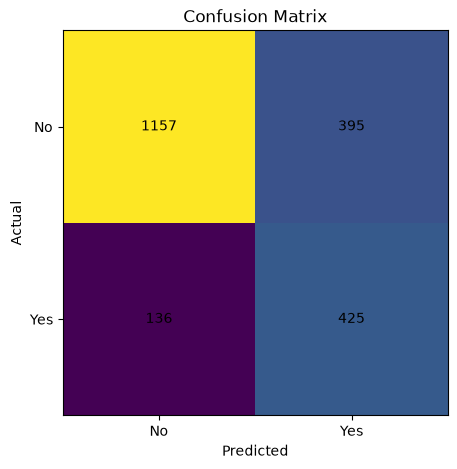

In [74]:
plt.figure(figsize=(6,5)); plt.imshow(cm); plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0,1],["No","Yes"]); plt.yticks([0,1],["No","Yes"])
for i in range(2):
    for j in range(2): plt.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.show()

## 6. Model interpretation

In [75]:
names=final_model.named_steps["preprocessor"].get_feature_names_out()
imp=pd.DataFrame({"Feature":names,"Importance":final_model.named_steps["classifier"].feature_importances_}).sort_values("Importance",ascending=False)
display(imp.head(15))

,Feature,Importance
38,cat__Contract_Month-to-month,0.653438
1,num__tenure,0.113895
18,cat__InternetService_Fiber optic,0.108821
2,num__MonthlyCharges,0.038365
20,cat__OnlineSecurity_No,0.019917
24,cat__OnlineBackup_No internet service,0.017697
29,cat__TechSupport_No,0.015850
45,cat__PaymentMethod_Electronic check,0.015369
39,cat__Contract_One year,0.006365
3,num__TotalCharges,0.005831


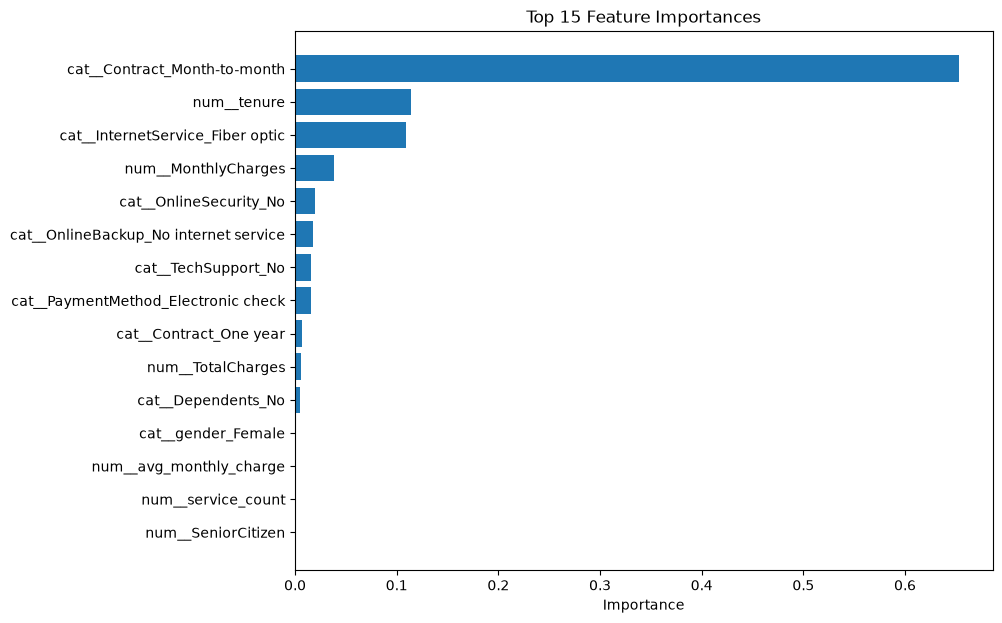

In [76]:
top=imp.head(15).sort_values("Importance")
plt.figure(figsize=(9,7)); plt.barh(top["Feature"],top["Importance"]); plt.title("Top 15 Feature Importances"); plt.xlabel("Importance"); plt.show()

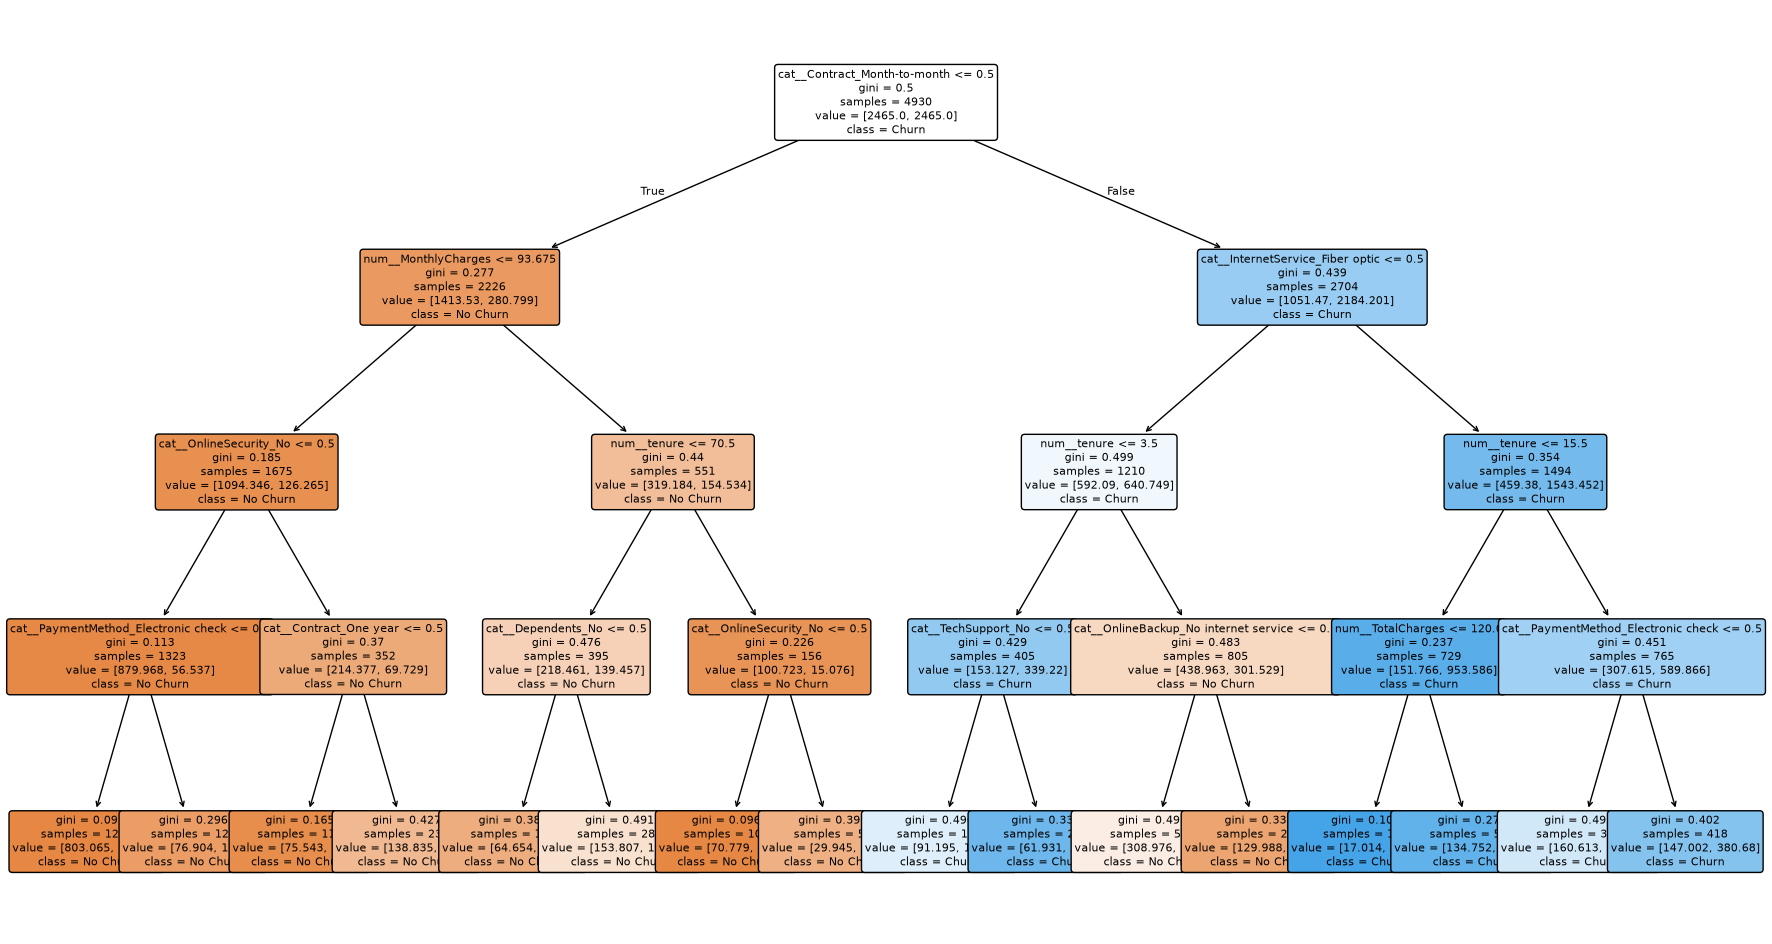

In [77]:
plt.figure(figsize=(22,12))
plot_tree(final_model.named_steps["classifier"],feature_names=names,class_names=["No Churn","Churn"],filled=True,rounded=True,max_depth=4,fontsize=8)
plt.show()

Because categorical variables are one-hot encoded, importance is shown at category level. In the business presentation, related categories should be grouped back to the original variable (for example, Contract or PaymentMethod).

## 7. Business Decision Layer — From Prediction to Retention Action

A churn model creates business value only when its predictions are converted into **prioritized retention actions**.

The operating concept is:

**Customer Data → Churn Prediction → Risk Segmentation → Retention Action → Outcome Measurement**

The model probability is used as a risk signal. It should not be interpreted as certainty that a customer will churn.

In [78]:
# Create a customer-level scoring dataset from the held-out test set.
scored_customers = X_test.copy()
scored_customers["actual_churn"] = y_test.values
scored_customers["churn_probability"] = final_model.predict_proba(X_test)[:, 1]
scored_customers["prediction"] = np.where(scored_customers["churn_probability"] >= 0.50, "Yes", "No")

# Business risk bands.
def risk_band(p):
    if p >= 0.75:
        return "High Risk"
    elif p >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

scored_customers["risk_band"] = scored_customers["churn_probability"].apply(risk_band)

display(
    scored_customers[
        ["customerID", "churn_probability", "prediction", "risk_band", "Contract",
         "tenure", "MonthlyCharges", "InternetService", "PaymentMethod"]
    ].sort_values("churn_probability", ascending=False).head(20)
)

,customerID,churn_probability,prediction,risk_band,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod
5393,5376-DEQCP,0.942506,Yes,High Risk,Month-to-month,1,70.60,Fiber optic,Electronic check
5300,8821-XNHVZ,0.942506,Yes,High Risk,Month-to-month,1,80.05,Fiber optic,Mailed check
5706,5196-SGOAK,0.942506,Yes,High Risk,Month-to-month,1,75.70,Fiber optic,Electronic check
5474,4912-PIGUY,0.942506,Yes,High Risk,Month-to-month,1,84.60,Fiber optic,Electronic check
2194,2514-GINMM,0.942506,Yes,High Risk,Month-to-month,1,79.50,Fiber optic,Electronic check
1731,8375-DKEBR,0.942506,Yes,High Risk,Month-to-month,1,69.60,Fiber optic,Electronic check
5826,9507-EXLTT,0.942506,Yes,High Risk,Month-to-month,1,79.35,Fiber optic,Bank transfer (automatic)
2753,6857-VWJDT,0.942506,Yes,High Risk,Month-to-month,1,95.65,Fiber optic,Mailed check
4556,3750-CKVKH,0.942506,Yes,High Risk,Month-to-month,2,67.75,Fiber optic,Electronic check
5943,2202-CUYXZ,0.942506,Yes,High Risk,Month-to-month,1,84.85,Fiber optic,Electronic check


### Risk segmentation

| Risk band | Model signal | Suggested business treatment |
|---|---|---|
| **High Risk** | Probability ≥ 75% | Prioritized retention outreach; investigate service/value issue; consider targeted offer |
| **Medium Risk** | 50–74.99% | Proactive digital engagement, service education and targeted incentives |
| **Low Risk** | < 50% | Normal engagement and cross-sell/loyalty activity |

These bands are **operational rules for the prototype**, not statistically calibrated probabilities or guaranteed customer outcomes. In production, the thresholds should be optimized using intervention cost, customer value and retention outcomes.

In [79]:
risk_summary = (
    scored_customers.groupby("risk_band")
    .agg(
        customers=("customerID", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        actual_churn_rate=("actual_churn", "mean"),
        avg_monthly_charge=("MonthlyCharges", "mean")
    )
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
    .reset_index()
)

risk_summary["estimated_monthly_revenue_at_risk"] = (
    risk_summary["customers"] * risk_summary["actual_churn_rate"] * risk_summary["avg_monthly_charge"]
)

display(risk_summary.round(3))

,risk_band,customers,avg_churn_probability,actual_churn_rate,avg_monthly_charge,estimated_monthly_revenue_at_risk
0,High Risk,398,0.841,0.656,73.229,19112.643
1,Medium Risk,422,0.627,0.389,76.391,12528.104
2,Low Risk,1293,0.217,0.105,57.642,7839.280


### Retention playbook

The model should feed a **closed-loop retention process** rather than simply producing a Yes/No label.

**High Risk**
- Route to retention team.
- Review contract, tenure, monthly charges and service configuration.
- Check whether a service-quality or value concern can be addressed.
- Offer a targeted retention intervention where economically justified.

**Medium Risk**
- Use automated/digital engagement first.
- Promote relevant service bundles, support or plan options.
- Escalate to human outreach if risk increases.

**Low Risk**
- Continue normal lifecycle communications.
- Use loyalty and cross-sell opportunities.
- Avoid unnecessary discounts.

The exact offer should be determined by business rules, customer value and intervention economics—not by the churn model alone.

### Closed-loop measurement

After an intervention, capture:

1. Customer risk score before intervention
2. Intervention type
3. Incentive/discount cost
4. Contact/delivery status
5. Customer response
6. Retention outcome
7. Revenue retained
8. Incremental profit

This allows the business to move from **prediction** to **prescriptive retention** and eventually evaluate which interventions actually reduce churn.

In [80]:
# Illustrative business prioritization view.
# This is a prioritization heuristic, not a causal estimate of retained revenue.
scored_customers["customer_value"] = scored_customers["MonthlyCharges"]

scored_customers["priority_score"] = (
    scored_customers["churn_probability"] * scored_customers["customer_value"]
)

priority_customers = scored_customers.sort_values(
    "priority_score", ascending=False
)

display(
    priority_customers[
        ["customerID", "churn_probability", "risk_band",
         "MonthlyCharges", "Contract", "tenure", "priority_score"]
    ].head(20)
)

,customerID,churn_probability,risk_band,MonthlyCharges,Contract,tenure,priority_score
2246,7181-BQYBV,0.942506,High Risk,102.45,Month-to-month,1,96.559750
1568,3292-PBZEJ,0.833521,High Risk,111.40,Month-to-month,11,92.854291
880,9851-KIELU,0.833521,High Risk,110.10,Month-to-month,10,91.770713
1176,3992-YWPKO,0.833521,High Risk,109.90,Month-to-month,6,91.604009
2753,6857-VWJDT,0.942506,High Risk,95.65,Month-to-month,1,90.150709
6866,0295-PPHDO,0.942506,High Risk,95.45,Month-to-month,1,89.962207
3380,5178-LMXOP,0.942506,High Risk,95.10,Month-to-month,1,89.632330
3772,0684-AOSIH,0.942506,High Risk,95.00,Month-to-month,1,89.538080
2294,2027-FECZV,0.833521,High Risk,106.70,Month-to-month,12,88.936740
6894,1400-MMYXY,0.833521,High Risk,105.90,Month-to-month,3,88.269923


### Architecture

```text
                    ┌────────────────────┐
                    │ Customer Data      │
                    │ CRM / Billing /    │
                    │ Service Data       │
                    └─────────┬──────────┘
                              │
                              ▼
                    ┌────────────────────┐
                    │ Data Preparation   │
                    │ + Feature Eng.     │
                    └─────────┬──────────┘
                              │
                              ▼
                    ┌────────────────────┐
                    │ Churn ML Model     │
                    │ Decision Tree      │
                    └─────────┬──────────┘
                              │
                  Churn probability
                              │
                              ▼
                    ┌────────────────────┐
                    │ Risk Segmentation  │
                    │ High / Medium /    │
                    │ Low                │
                    └─────────┬──────────┘
                              │
                              ▼
                    ┌────────────────────┐
                    │ Retention         │
                    │ Decision Engine    │
                    └─────────┬──────────┘
                              │
              ┌───────────────┼────────────────┐
              ▼               ▼                ▼
        Human outreach   Digital nudge    No intervention
              │               │                │
              └───────────────┼────────────────┘
                              ▼
                    ┌────────────────────┐
                    │ Outcome Tracking   │
                    │ Retained / Churned │
                    │ Cost / Revenue     │
                    └─────────┬──────────┘
                              │
                              ▼
                    ┌────────────────────┐
                    │ Model & Strategy   │
                    │ Monitoring         │
                    └────────────────────┘
```

This separates **prediction** from **business action**, which is important: the ML model estimates risk, while the retention layer determines what action is appropriate.

## 8. API + Business Layer

The API currently returns the model prediction and probability. A production-oriented extension can return the risk band and recommended action as well:

```json
{
  "prediction": "Yes",
  "churn_probability": 0.82,
  "risk_band": "High Risk",
  "recommended_action": "Prioritized retention outreach"
}
```

The recommendation is a business rule layered on top of the model. Keeping it separate means the retention strategy can evolve without retraining the ML model.

## 9. Save model and API
The saved artifact is the **complete preprocessing + feature engineering + classifier pipeline**, not only the tree. This is important for applying exactly the same transformations to new customers.

Run:
```bash
uvicorn app:app --reload
```
Swagger: `http://127.0.0.1:8000/docs`

Endpoint: `POST /predict`